### 1/ system coefficients and skill initialization
initialized static parameters, experience and skill consistency.
hyperparams(alpha, beta, gamma)

### 2/ fatigue calculation, z

delta z gain = alpha * shot *exp(0.15) +beta *delta HR

delta z drain = z fatigue * (gamma * t rest)

z fatigue(t) = clip (z fatigue(t1) + delta z gain - delta z drain, 0,1)

### 3/ hard coded failure boundary
binary step switch for biological breakdown

before 0.75: the biomechanical parameters (tremor level, release angle error) remain contrained around baseline gaussian noise

after 0.74: noise explodes exponentially using this multiplier
compensation factor = exp (5 * (z fatigue - 0.75))

### 4/ target metric
arrow distance from center acts as an open loop output vector

### 5/ output to input feedback loop
bad previous outcomes back propogates into future shots. if rolling trend decreases, the previous performance state has increase in pressure level on shot t plus 1.

### here's the mechanism breakdown:

1/ Latent State Features: these are internal physiological and cognitive conditions that cannot be observed directly but influence how an athlete performs.
2/ Physical Mechanism Features: the consistency of movement execution that translate intention into action.
3/ Environmental Features: external conditions that introduce disturbance
4/ Context Features: info about history, temporal progression that provide context for each observation.
5/ Output Variables: measurable outcome emerged from interaction of all previous mechanisms

In [1]:
import numpy as np
import pandas as pd

def generate_archery_dataset(num_shots=200):
    np.random.seed(42)

    # -------------------------------------------------------------
    # Hyperparameters & System Coefficients
    # -------------------------------------------------------------
    alpha = 0.025  # Rate of fatigue accumulation per shot unit
    beta = 0.005   # Impact of increasing heart rate on physical stress
    gamma = 0.0004 # Efficiency of recovery time on draining fatigue
    
    # -------------------------------------------------------------
    # Skill Priors & Static Traits (Layer 1 - Initialization)
    # -------------------------------------------------------------
    experience = np.random.uniform(2, 15)       # Experience in years
    skill_consistency = np.random.uniform(0.6, 0.95) # Baseline skill level (0-1)

    # Latent state tracking initialization at t=0
    fatigue_level = 0.1          # Scale 0-1
    baseline_heart_rate = 70.0  
    time_since_start = 0.0       # Cumulative clock time in seconds
    previous_performance_state = 0.0 # Starts neutral (Scale -5 to +5)
    previous_shot_variability = 0.1
    
    # Historical queue to track the last 5 shots for rolling performance metrics
    shot_history = []
    dataset = []

    for shot in range(1, num_shots + 1):
        # 4) Context Features: Temporal Progression
        shot_number = shot
        round_number = int((shot - 1) // 6) + 1  # 6 shots per standard end/round
        
        # Simulating rest period and time accumulation
        recovery_time_before_shot = np.random.uniform(30, 90) # seconds
        time_since_start += recovery_time_before_shot + 15.0 # Adds 15s setup window per shot

        # -------------------------------------------------------------
        # 1) Core Latent State Layer
        # -------------------------------------------------------------
        
        # A. Mental Cognitive State
        # Pressure increases as tournament progresses, modulated by experience dampening
        base_pressure = (shot_number / num_shots) * 0.5 + np.random.uniform(0.1, 0.3)
        pressure_level = np.clip(base_pressure / (1.0 + (experience * 0.05)), 0.0, 1.0)
        
        # Performance drop under pressure scales negatively with skill level
        performance_drop_under_pressure = max(0.0, (pressure_level - 0.5) * (1.0 - skill_consistency))
        
        # B. Physical State Logic (Temporal Accumulation with Dynamic Memory)
        shot_load = shot ** 0.15
        
        # Heart rate response drifts up organically based on baseline fatigue and mental pressure
        heart_rate_change = np.random.uniform(5, 20) + (fatigue_level * 40) + (pressure_level * 15)
        heart_rate_during_shot = baseline_heart_rate + heart_rate_change
        
        # State Transitions: Past State + Exertion Gain + Stress Gain - Recovery Drain
        fatigue_gain = (alpha * shot_load) + (beta * heart_rate_change)
        recovery_drain = fatigue_level * (gamma * recovery_time_before_shot)
        fatigue_level = np.clip(fatigue_level + fatigue_gain - recovery_drain, 0.0, 1.0)
        
        # Comprehensive Fatigue State Function
        fatigue_state = fatigue_level + (shot_number * 0.001) + (time_since_start * 0.0001) + (heart_rate_change * 0.002) - (recovery_time_before_shot * 0.0005)
        recovery_response = recovery_drain / (fatigue_gain + 1e-6)

        # C. Combined State Coupled Interactions
        pressure_response = pressure_level * 0.4 + (heart_rate_change / 100.0) * 0.4 + performance_drop_under_pressure * 0.2
        
        # -------------------------------------------------------------
        # 3) Environment Variables Layer
        # -------------------------------------------------------------
        wind_speed = np.random.uniform(0, 25)       # km/hr
        wind_direction = np.random.uniform(0, 360)   # degrees
        wind_gust_variability = np.random.uniform(0, 8) # km/hr
        
        # Magnitude mapping for external disturbance
        environmental_disturbance_index = (wind_speed * np.abs(np.sin(np.radians(wind_direction)))) + wind_gust_variability
        
        # Thermal context environment
        temperature = np.random.uniform(18, 34) # Celsius
        humidity = np.random.uniform(40, 85)    # Percentage
        thermal_stress = (temperature * 0.5 + humidity * 0.2 + (time_since_start / 3600.0) * 0.3)

        # -------------------------------------------------------------
        # 1-B) Motor Stability State & 2) Physical Mechanism Features
        # -------------------------------------------------------------
        base_tremor = np.random.normal(1.0, 0.05)
        
        # Non-Linear Compensation Threshold Boundary Check
        if fatigue_level > 0.75:
            # Beyond 0.75: Complete structural breakdown
            compensation_breakdown_factor = np.exp((fatigue_level - 0.75) * 5)
            tremor_level = base_tremor * compensation_breakdown_factor
            
            # Mechanical consequences erode exponentially
            release_angle_error = np.random.normal(0.05, 0.01) * (1.0 + fatigue_level * 5)
            bow_alignment_variability = np.random.normal(0.1, 0.02) * (1.0 + fatigue_level * 4)
            anchor_variation = np.random.normal(0.5, 0.1) * (1.0 + fatigue_level * 3)
            force_consistency = np.random.normal(50.0, 5.0) / (1.0 + fatigue_level * 0.5)
        else:
            # Before 0.75: Active biological & cognitive stabilization
            tremor_level = base_tremor
            release_angle_error = np.random.normal(0.05, 0.01) * 1.1
            bow_alignment_variability = np.random.normal(0.1, 0.02) * 1.05
            anchor_variation = np.random.normal(0.5, 0.05)
            force_consistency = np.random.normal(50.0, 1.5)

        # Additional latent target properties
        stability = 1.0 - np.clip((tremor_level + bow_alignment_variability + anchor_variation) / 10.0, 0.0, 1.0)
        motor_stability_state = tremor_level * 0.4 + bow_alignment_variability * 0.3 + anchor_variation * 0.2 + release_angle_error * 0.1
        stability_state = np.sin(shot_number) * stability  # Models sequenced oscillation profiles

        # -------------------------------------------------------------
        # 4 & 5) Output Target Mapping & Uncertainty Mechanics
        # -------------------------------------------------------------
        shot_noise_factor = np.random.uniform(0.0, 1.0)
        unexplained_variability = shot_noise_factor * 0.3 # Random noise buffer
        
        # Final Execution Equation linking Hidden States, Mechanics, Environment and Target
        arrow_distance_from_center = (
            (tremor_level * 2.5) + 
            (release_angle_error * 12.0) + 
            (bow_alignment_variability * 8.0) +
            (anchor_variation * 1.5) +
            (environmental_disturbance_index * 0.15) +
            (performance_drop_under_pressure * 3.0) -
            (force_consistency * 0.02) + 
            np.random.normal(0, 0.2) + 
            unexplained_variability
        )
        
        # Handle logical ceiling constraints for physical outputs
        arrow_distance_from_center = max(0.0, arrow_distance_from_center)
        
        # Calculate trailing history indicators (Rolling metrics based on last 5 shots)
        shot_history.append(arrow_distance_from_center)
        if len(shot_history) > 5:
            shot_history.pop(0)
            
        rolling_mean = np.mean(shot_history)
        rolling_variance = np.var(shot_history) if len(shot_history) > 1 else 0.0
        rolling_trend = (shot_history[-1] - shot_history[0]) if len(shot_history) > 1 else 0.0
        rolling_performance_state = {"mean": rolling_mean, "variance": rolling_variance, "trend": rolling_trend}
        
        # Track historical momentum state metrics for the NEXT loop sequence
        if shot > 1:
            momentum_feature = rolling_trend
            previous_performance_state = np.clip(rolling_trend * -1, -5.0, 5.0) # Mapping bad trends to negative states
            previous_shot_variability = np.abs(arrow_distance_from_center - rolling_mean)
        else:
            momentum_feature = 0.0
            
        # Append finalized structure row to the master collection matrix
        dataset.append({
            # 4) Context / Telemetry Group
            "shot_number": shot_number,
            "round_number": round_number,
            "time_since_start_seconds": time_since_start,
            
            # 1) Latent Physical & Skill State Metrics
            "experience_years": experience,
            "skill_consistency": skill_consistency,
            "fatigue_level": fatigue_level,
            "fatigue_state": fatigue_state,
            "recovery_time_before_shot": recovery_time_before_shot,
            "recovery_response": recovery_response,
            "heart_rate_change_bpm": heart_rate_change,
            "heart_rate_during_shot": heart_rate_during_shot,
            
            # 1) Cognitive States
            "pressure_level": pressure_level,
            "performance_drop_under_pressure": performance_drop_under_pressure,
            "pressure_response": pressure_response,
            "momentum_feature": momentum_feature,
            "previous_performance_state": previous_performance_state,
            
            # 1 & 2) Motor Control / Mechanical Features
            "tremor_level": tremor_level,
            "stability_score": stability,
            "motor_stability_state": motor_stability_state,
            "stability_state_sequence": stability_state,
            "release_angle_error_deg": release_angle_error,
            "bow_alignment_variability_deg": bow_alignment_variability,
            "anchor_variation_mm": anchor_variation,
            "force_consistency_newtons": force_consistency,
            
            # 3) Environment Metrics
            "wind_speed_kmhr": wind_speed,
            "wind_direction_deg": wind_direction,
            "wind_gust_variability_kmhr": wind_gust_variability,
            "environmental_disturbance_index": environmental_disturbance_index,
            "thermal_stress_index": thermal_stress,
            
            # 4 & 5) Noise & Outputs Target Group
            "shot_noise_factor": shot_noise_factor,
            "unexplained_variability": unexplained_variability,
            "rolling_performance_mean": rolling_performance_state["mean"],
            "rolling_performance_variance": rolling_performance_state["variance"],
            "rolling_performance_trend": rolling_performance_state["trend"],
            "previous_shot_variability": previous_shot_variability,
            "arrow_distance_from_center_cm": arrow_distance_from_center
        })

    return pd.DataFrame(dataset)

# Execute verification buildno
df_archery = generate_archery_dataset(200)
print(f"Generated Dataset Shape: {df_archery.shape}")

Generated Dataset Shape: (200, 36)


In [2]:
df_archery.head()

,shot_number,round_number,time_since_start_seconds,experience_years,skill_consistency,fatigue_level,fatigue_state,recovery_time_before_shot,recovery_response,heart_rate_change_bpm,...,wind_gust_variability_kmhr,environmental_disturbance_index,thermal_stress_index,shot_noise_factor,unexplained_variability,rolling_performance_mean,rolling_performance_variance,rolling_performance_trend,previous_shot_variability,arrow_distance_from_center_cm
0,1,1,88.919637,6.869022,0.93275,0.191151,0.191726,73.919637,0.031419,13.821557,...,6.929409,8.321281,28.188983,0.431945,0.129584,4.638010,0.000000,0.000000,0.100000,4.638010
1,2,1,151.393385,6.869022,0.93275,0.301646,0.329603,47.473748,0.031806,17.277103,...,3.648560,9.085555,25.091088,0.097672,0.029302,5.170745,0.283807,1.065470,0.532735,5.703480
2,3,1,237.447367,6.869022,0.93275,0.427949,0.461326,71.053982,0.063563,21.079561,...,7.274563,9.928614,25.052728,0.088493,0.026548,5.059504,0.213954,0.199010,0.222483,4.837020
3,4,1,294.206338,6.869022,0.93275,0.593215,0.662410,41.758972,0.041460,28.327095,...,6.629900,16.259542,22.406954,0.074045,0.022213,5.388657,0.485491,1.738107,0.987460,6.376118
4,5,1,360.714282,6.869022,0.93275,0.828769,0.930466,51.507944,0.049327,43.189984,...,0.508467,14.120900,22.444568,0.760785,0.228236,7.472396,17.756264,11.169341,8.334955,15.807351


experience years and skill consistency represents the median for the provided range in the the code, which introduces an architectural trap which is information flattening or quotient mapping.
Compressing an archer's localized historical trajectory down to a single median value,it wipes away the dynamic variance and the continuous path-dependency (hysteresis) of their performance.
The Homogeneity Leak: treats an archer recovering from a high pressure failure same as archer with high confidence momentum, just because the median performance metrics looks identical.
Phase Transition Cushioning: the median smoothes out the edges, instead of capturing the sharp/ catastrophic motor breakdown when stress/pressure/fatigue spikes.

### plots:
the below graphs shows the correlation between the synthetic dataset features.

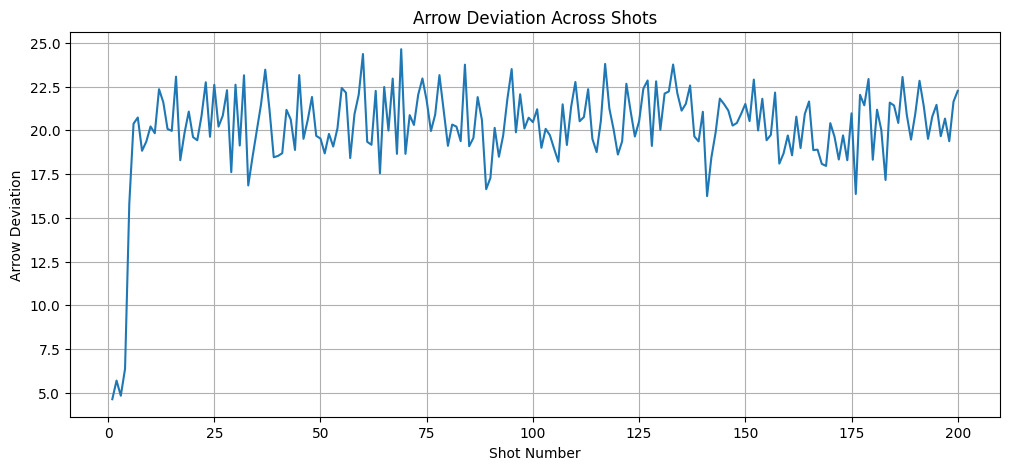

In [5]:
plt.figure(figsize=(12,5))

plt.plot(df_archery['shot_number'],
         df_archery['arrow_distance_from_center_cm'])

plt.xlabel('Shot Number')
plt.ylabel('Arrow Deviation')
plt.title('Arrow Deviation Across Shots')
plt.grid(True)
plt.show()

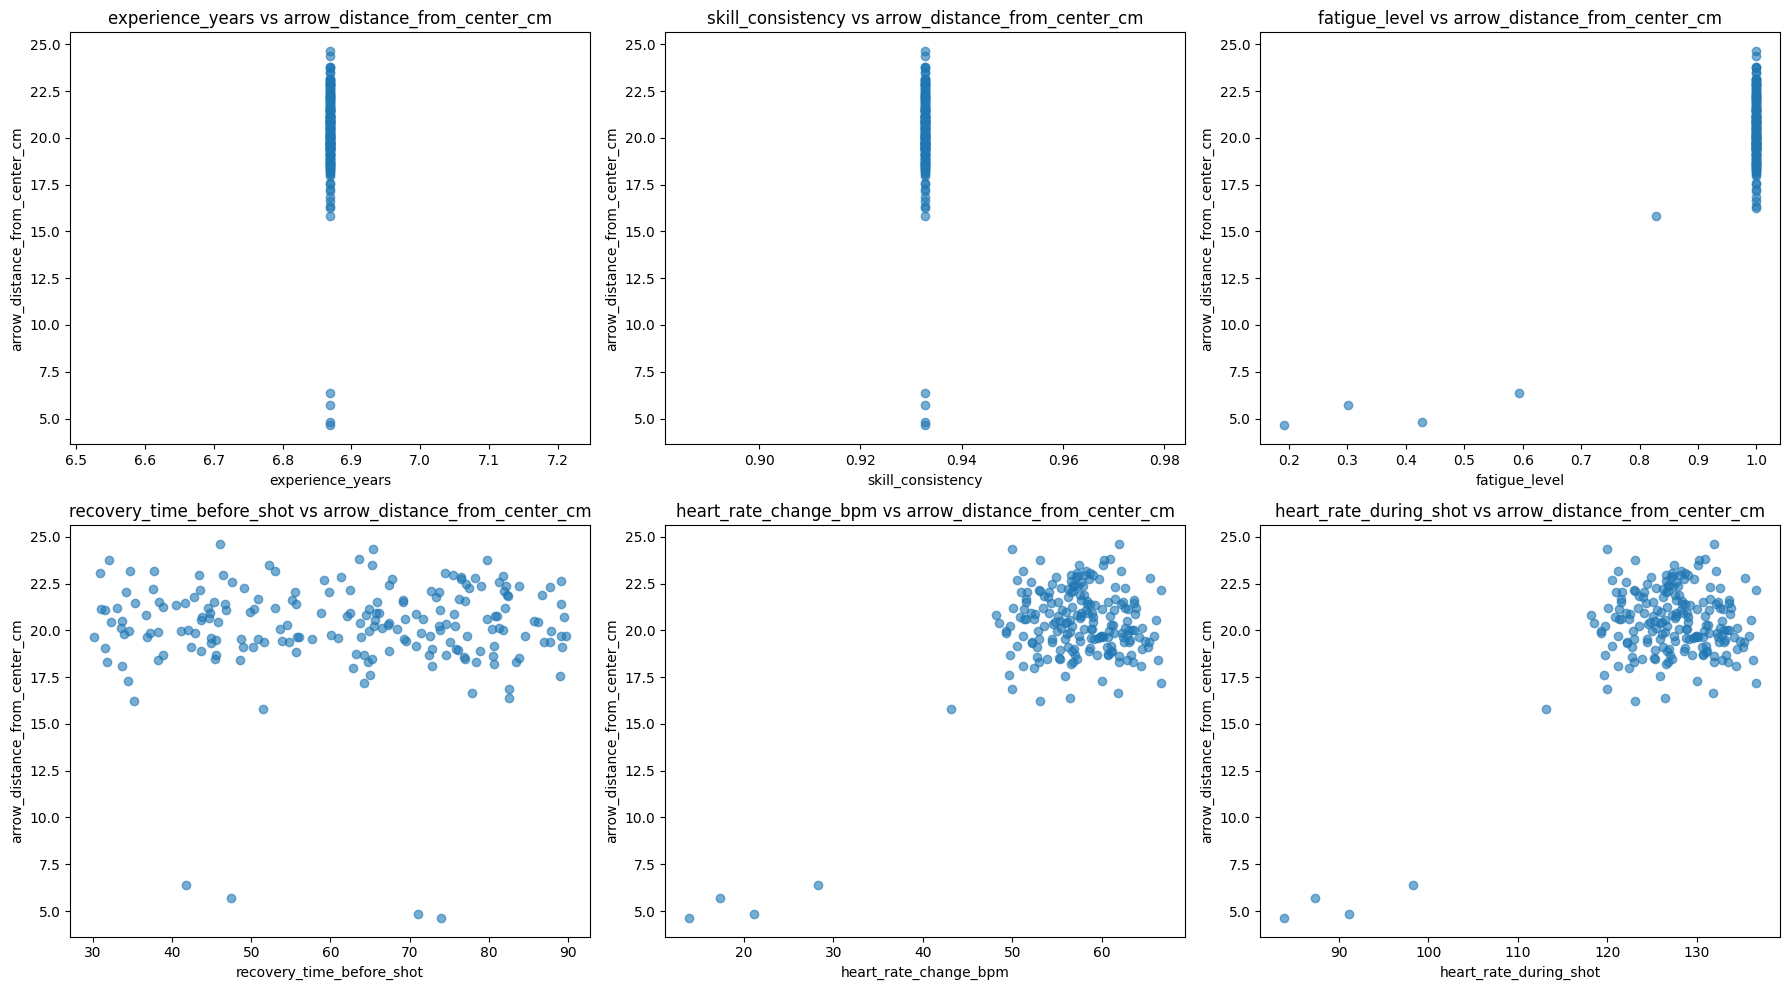

In [6]:
import matplotlib.pyplot as plt

features = [
    'experience_years',
    'skill_consistency',
    'fatigue_level',
    'recovery_time_before_shot',
    'heart_rate_change_bpm',
    'heart_rate_during_shot'
]

label = 'arrow_distance_from_center_cm'

plt.figure(figsize=(18,10))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    plt.scatter(df_archery[feature], df_archery[label], alpha=0.6)
    plt.xlabel(feature)
    plt.ylabel(label)
    plt.title(f'{feature} vs {label}')

plt.tight_layout()
plt.show()

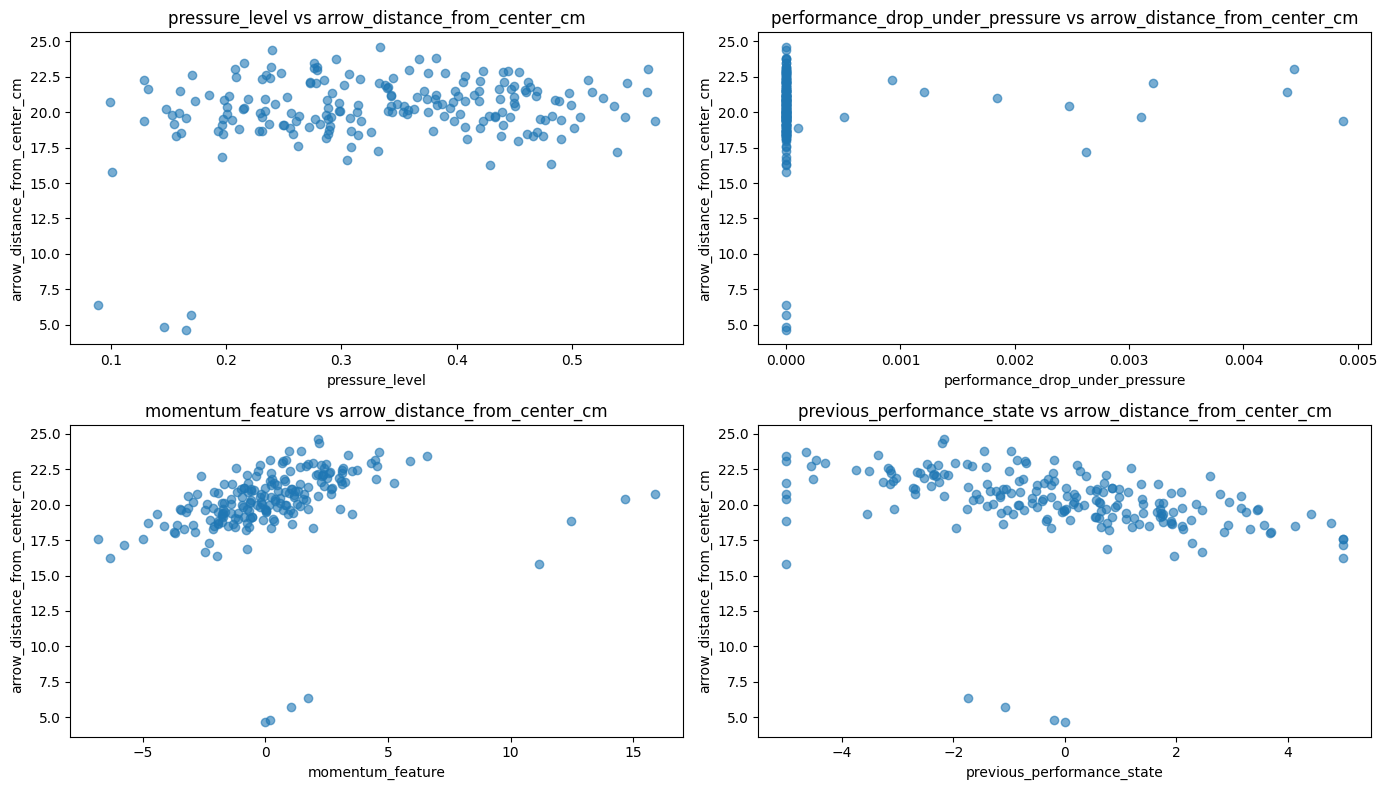

In [7]:
features = [
    'pressure_level',
    'performance_drop_under_pressure',
    'momentum_feature',
    'previous_performance_state'
]

plt.figure(figsize=(14,8))

for i, feature in enumerate(features, 1):
    plt.subplot(2,2,i)
    plt.scatter(df_archery[feature], df_archery[label], alpha=0.6)
    plt.xlabel(feature)
    plt.ylabel(label)
    plt.title(f'{feature} vs {label}')

plt.tight_layout()
plt.show()

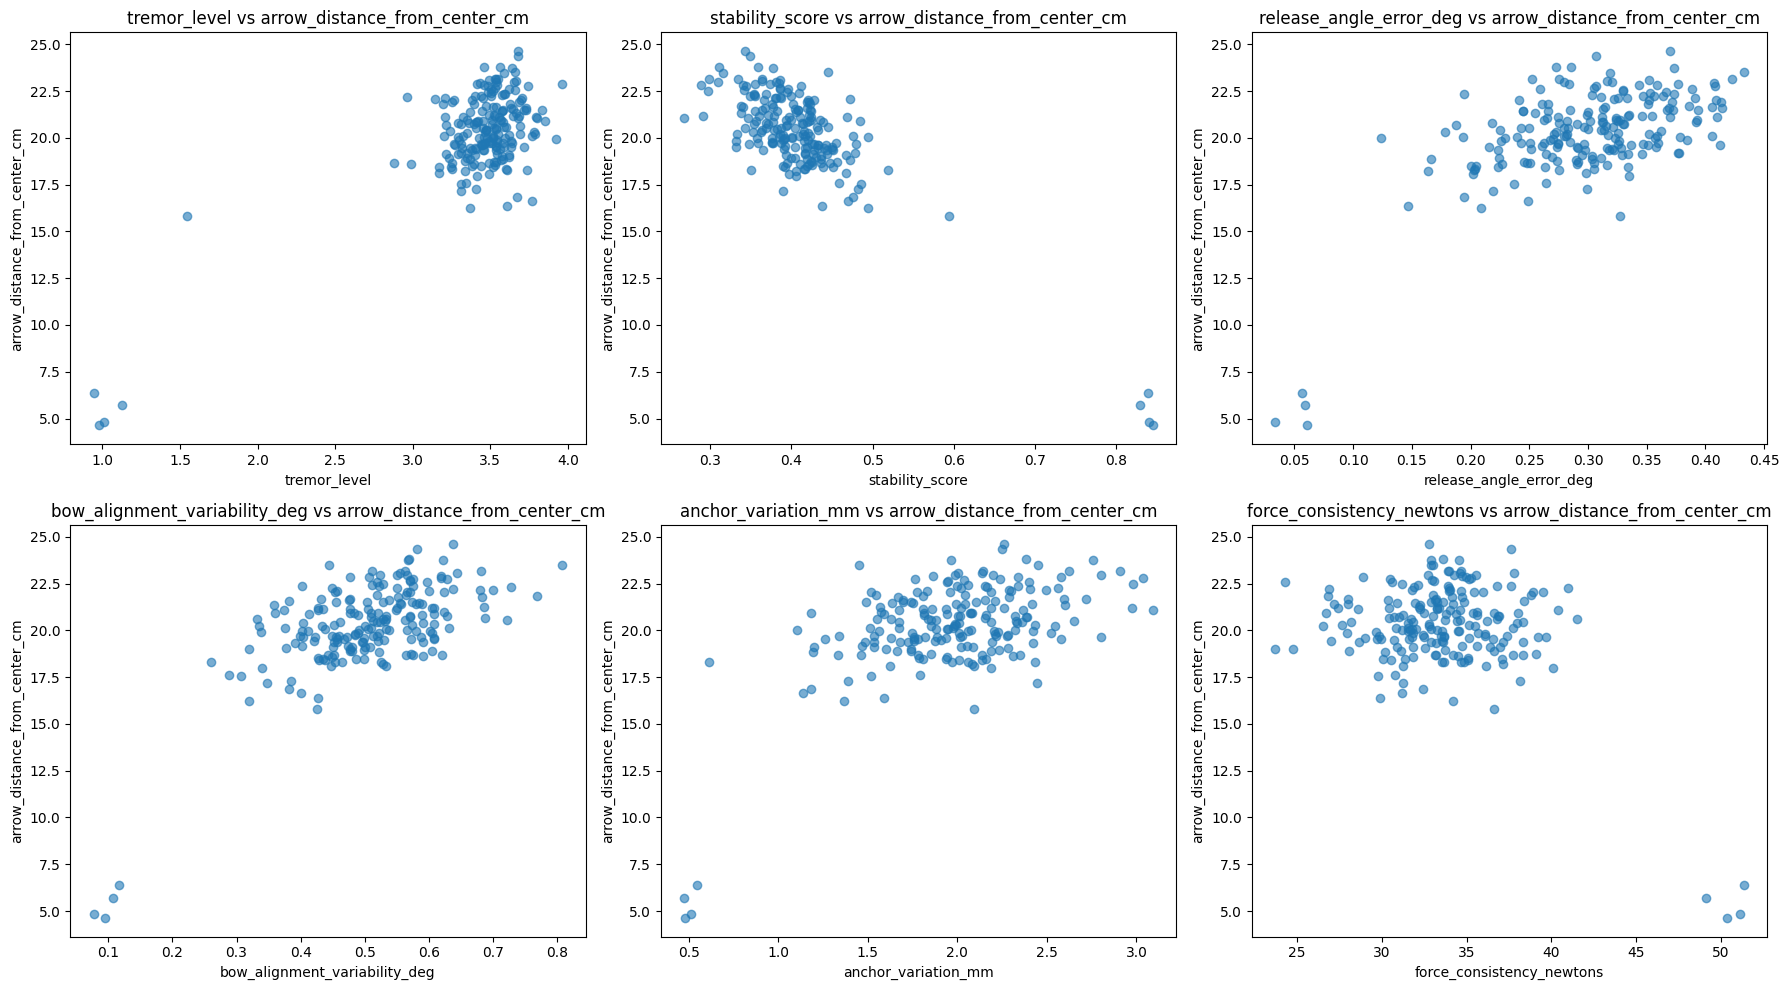

In [8]:
features = [
    'tremor_level',
    'stability_score',
    'release_angle_error_deg',
    'bow_alignment_variability_deg',
    'anchor_variation_mm',
    'force_consistency_newtons'
]

plt.figure(figsize=(18,10))

for i, feature in enumerate(features, 1):
    plt.subplot(2,3,i)
    plt.scatter(df_archery[feature], df_archery[label], alpha=0.6)
    plt.xlabel(feature)
    plt.ylabel(label)
    plt.title(f'{feature} vs {label}')

plt.tight_layout()
plt.show()

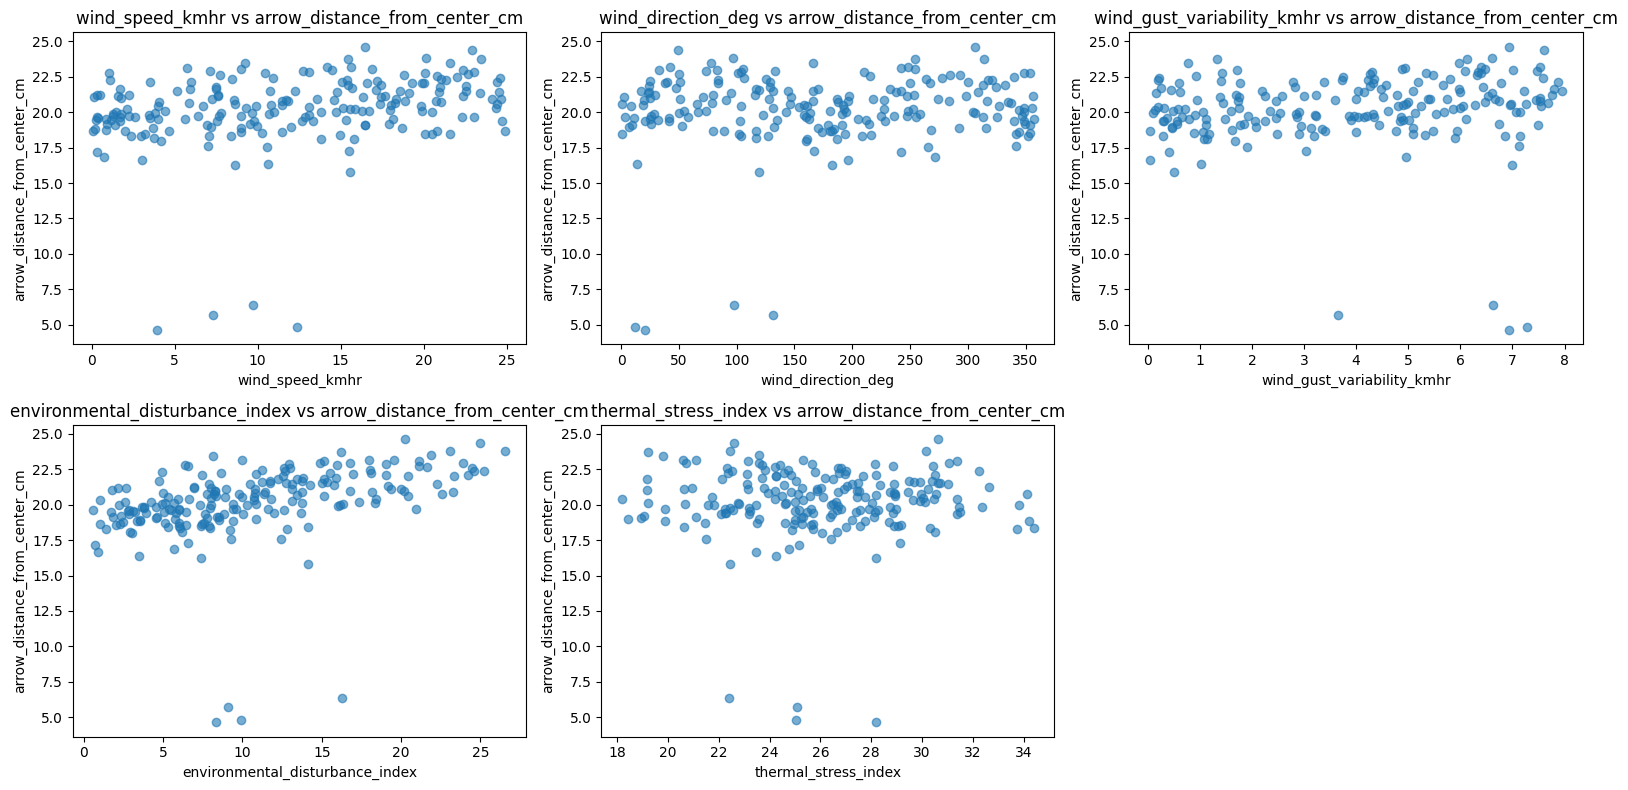

In [9]:
features = [
    'wind_speed_kmhr',
    'wind_direction_deg',
    'wind_gust_variability_kmhr',
    'environmental_disturbance_index',
    'thermal_stress_index'
]

plt.figure(figsize=(16,8))

for i, feature in enumerate(features, 1):
    plt.subplot(2,3,i)
    plt.scatter(df_archery[feature], df_archery[label], alpha=0.6)
    plt.xlabel(feature)
    plt.ylabel(label)
    plt.title(f'{feature} vs {label}')

plt.tight_layout()
plt.show()

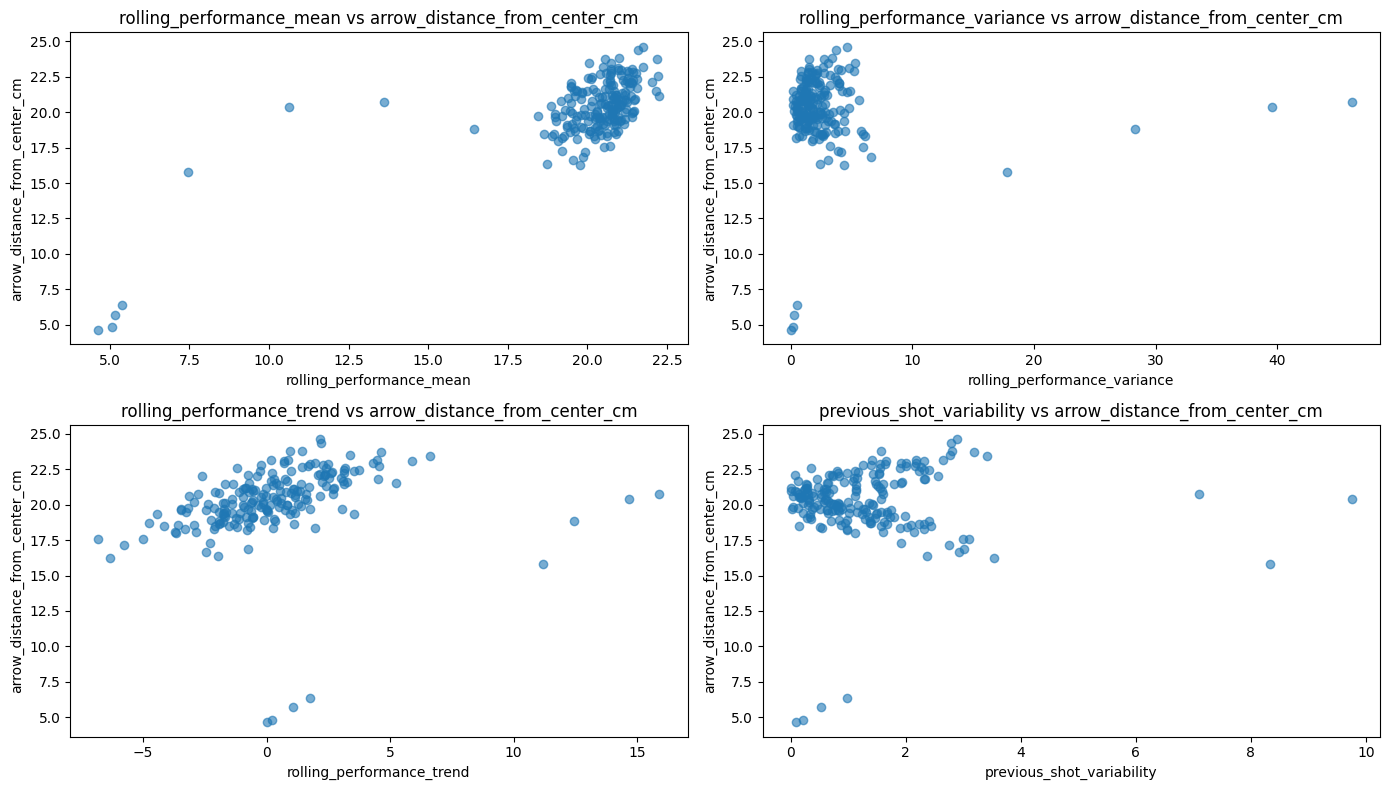

In [10]:
features = [
    'rolling_performance_mean',
    'rolling_performance_variance',
    'rolling_performance_trend',
    'previous_shot_variability'
]

plt.figure(figsize=(14,8))

for i, feature in enumerate(features, 1):
    plt.subplot(2,2,i)
    plt.scatter(df_archery[feature], df_archery[label], alpha=0.6)
    plt.xlabel(feature)
    plt.ylabel(label)
    plt.title(f'{feature} vs {label}')

plt.tight_layout()
plt.show()

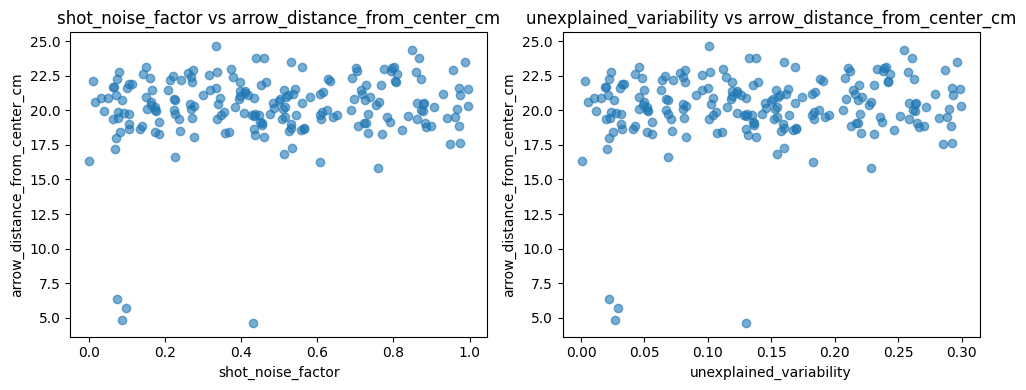

In [11]:
features = [
    'shot_noise_factor',
    'unexplained_variability'
]

plt.figure(figsize=(10,4))

for i, feature in enumerate(features, 1):
    plt.subplot(1,2,i)
    plt.scatter(df_archery[feature], df_archery[label], alpha=0.6)
    plt.xlabel(feature)
    plt.ylabel(label)
    plt.title(f'{feature} vs {label}')

plt.tight_layout()
plt.show()

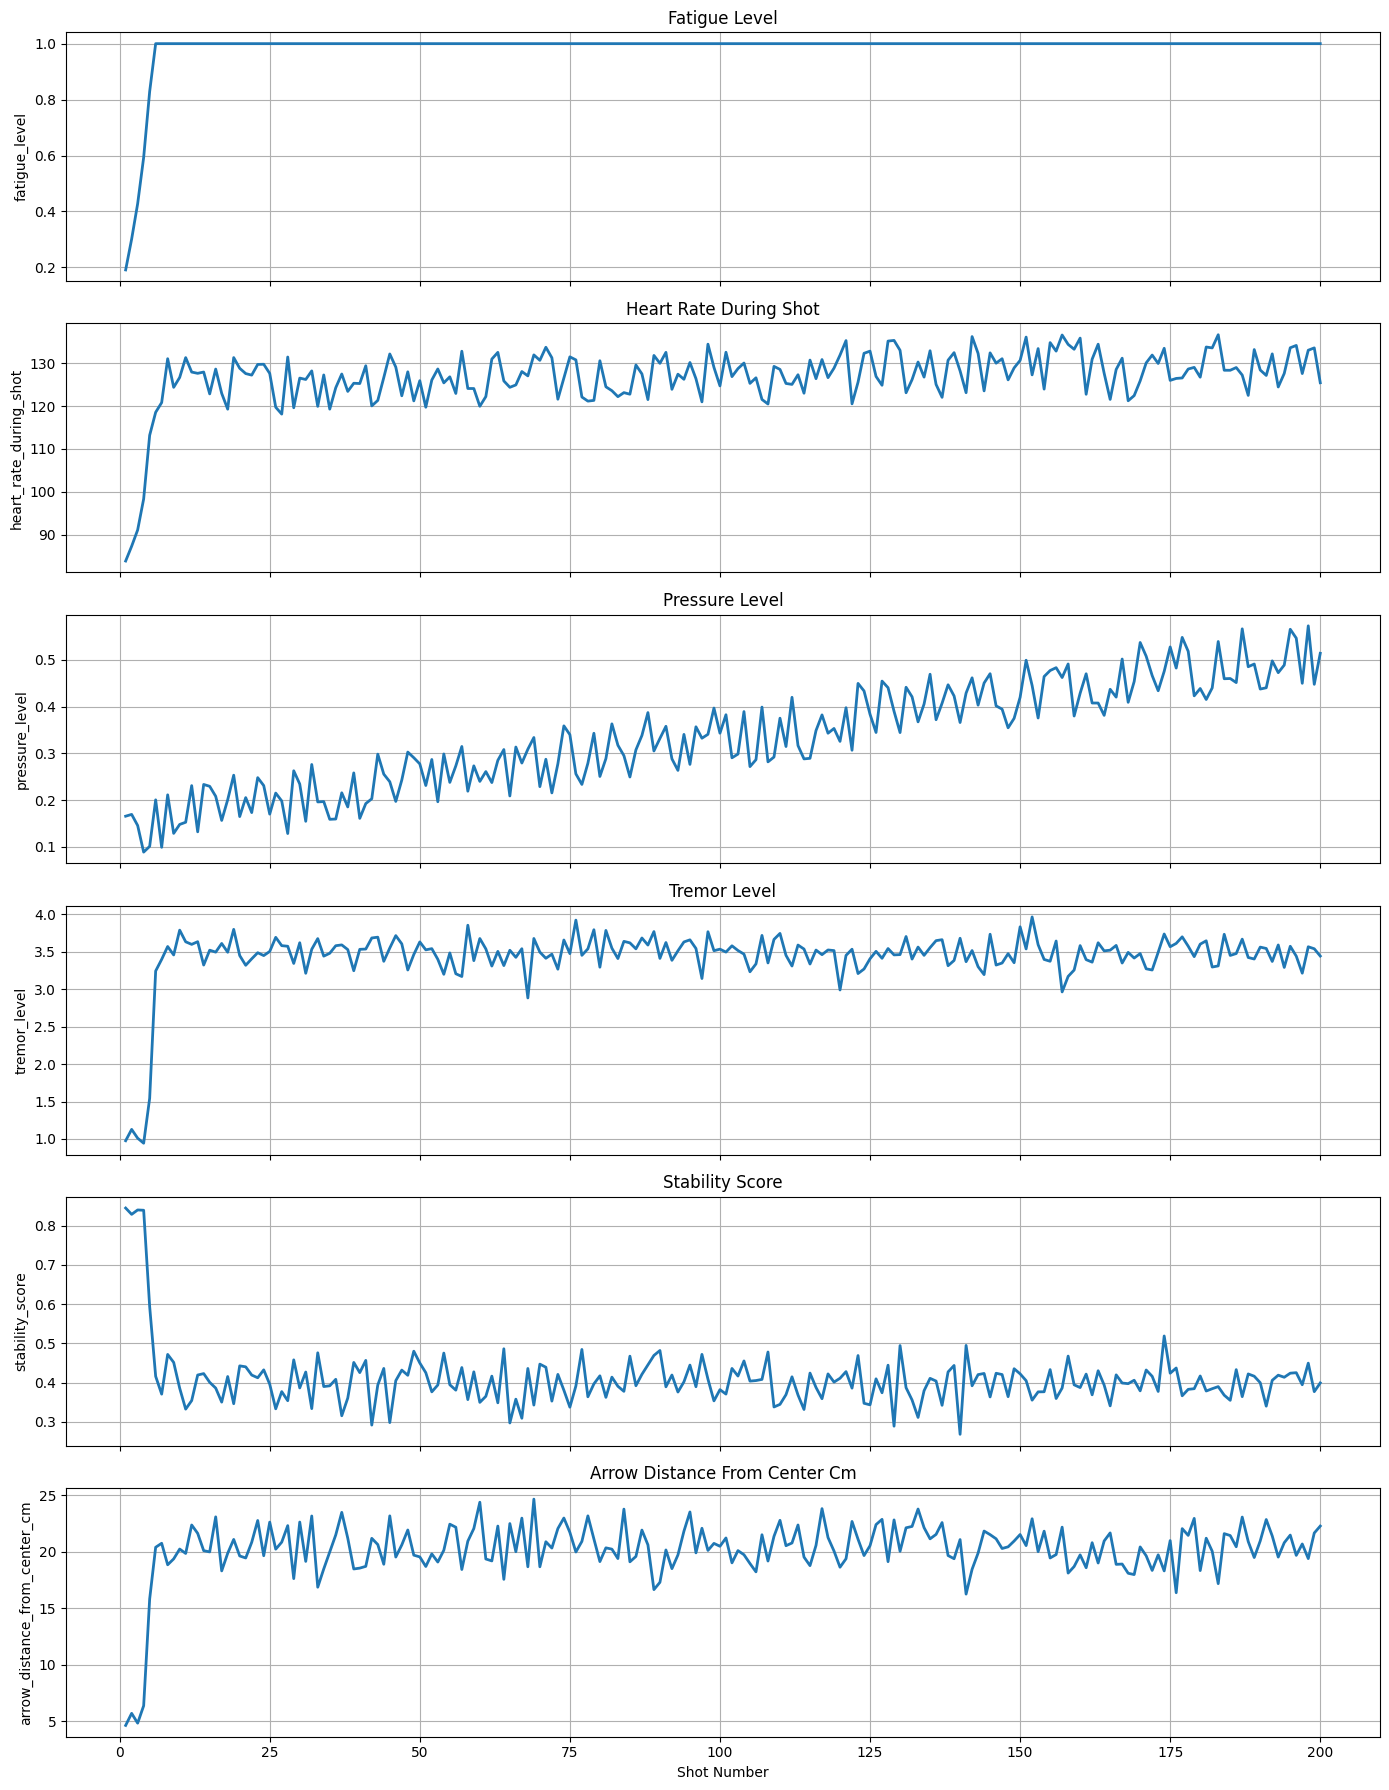

In [12]:
import matplotlib.pyplot as plt

features = [
    'fatigue_level',
    'heart_rate_during_shot',
    'pressure_level',
    'tremor_level',
    'stability_score',
    'arrow_distance_from_center_cm'
]

fig, axes = plt.subplots(len(features), 1,
                         figsize=(14,18),
                         sharex=True)

for ax, feature in zip(axes, features):

    ax.plot(df_archery['shot_number'],
            df_archery[feature],
            linewidth=2)

    ax.set_ylabel(feature)
    ax.set_title(feature.replace('_', ' ').title())
    ax.grid(True)

axes[-1].set_xlabel('Shot Number')

plt.tight_layout()
plt.show()

### the compensation breakdown 

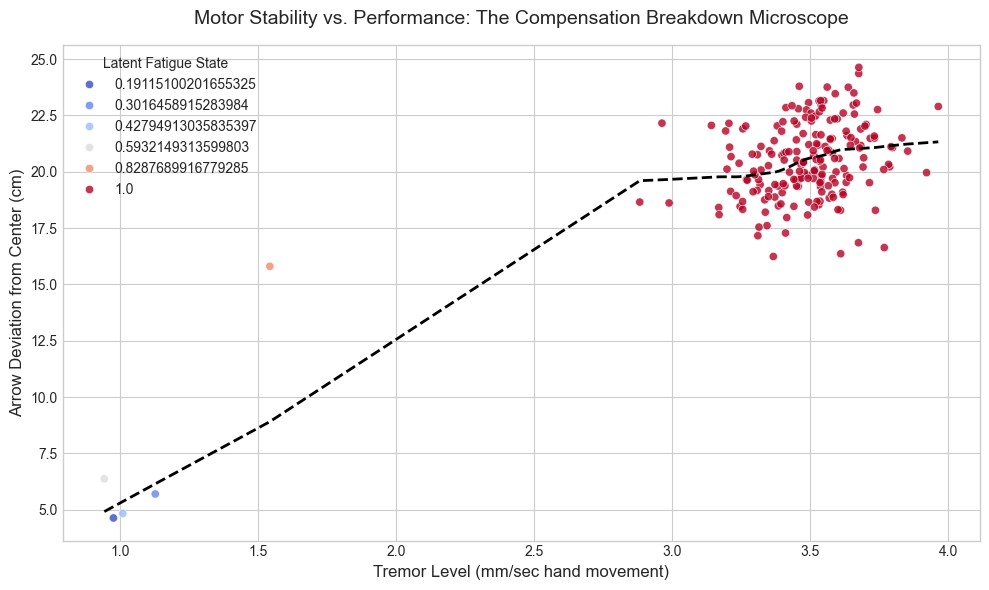

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for a clean, scientific look
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Create the scatter plot
sns.scatterplot(
    data=df_archery,
    x='tremor_level',
    y='arrow_distance_from_center_cm',
    hue='fatigue_level', # Color points by latent fatigue to see it creeping up
    palette='coolwarm',
    alpha=0.8,
    ax=ax
)

# 2. Add a non-linear smoothed line (LOWESS) to track the phase transition
sns.regplot(
    data=df_archery,
    x='tremor_level',
    y='arrow_distance_from_center_cm',
    scatter=False,
    lowess=True,
    line_kws={'color': 'black', 'linewidth': 2, 'linestyle': '--'},
    ax=ax
)

# 3. Annotate the graph to make the physics explicit
ax.set_title('Motor Stability vs. Performance: The Compensation Breakdown Microscope', fontsize=14, pad=15)
ax.set_xlabel('Tremor Level (mm/sec hand movement)', fontsize=12)
ax.set_ylabel('Arrow Deviation from Center (cm)', fontsize=12)

# Customize the legend to reflect the latent state
legend = ax.legend(title='Latent Fatigue State', loc='upper left')
frame = legend.get_frame()
frame.set_facecolor('white')

plt.tight_layout()
plt.show()

introducing more meaningful features in the dataset changes the relationship between tremor level and the ouput (arrow deviation from center)

### correlation within dataset features

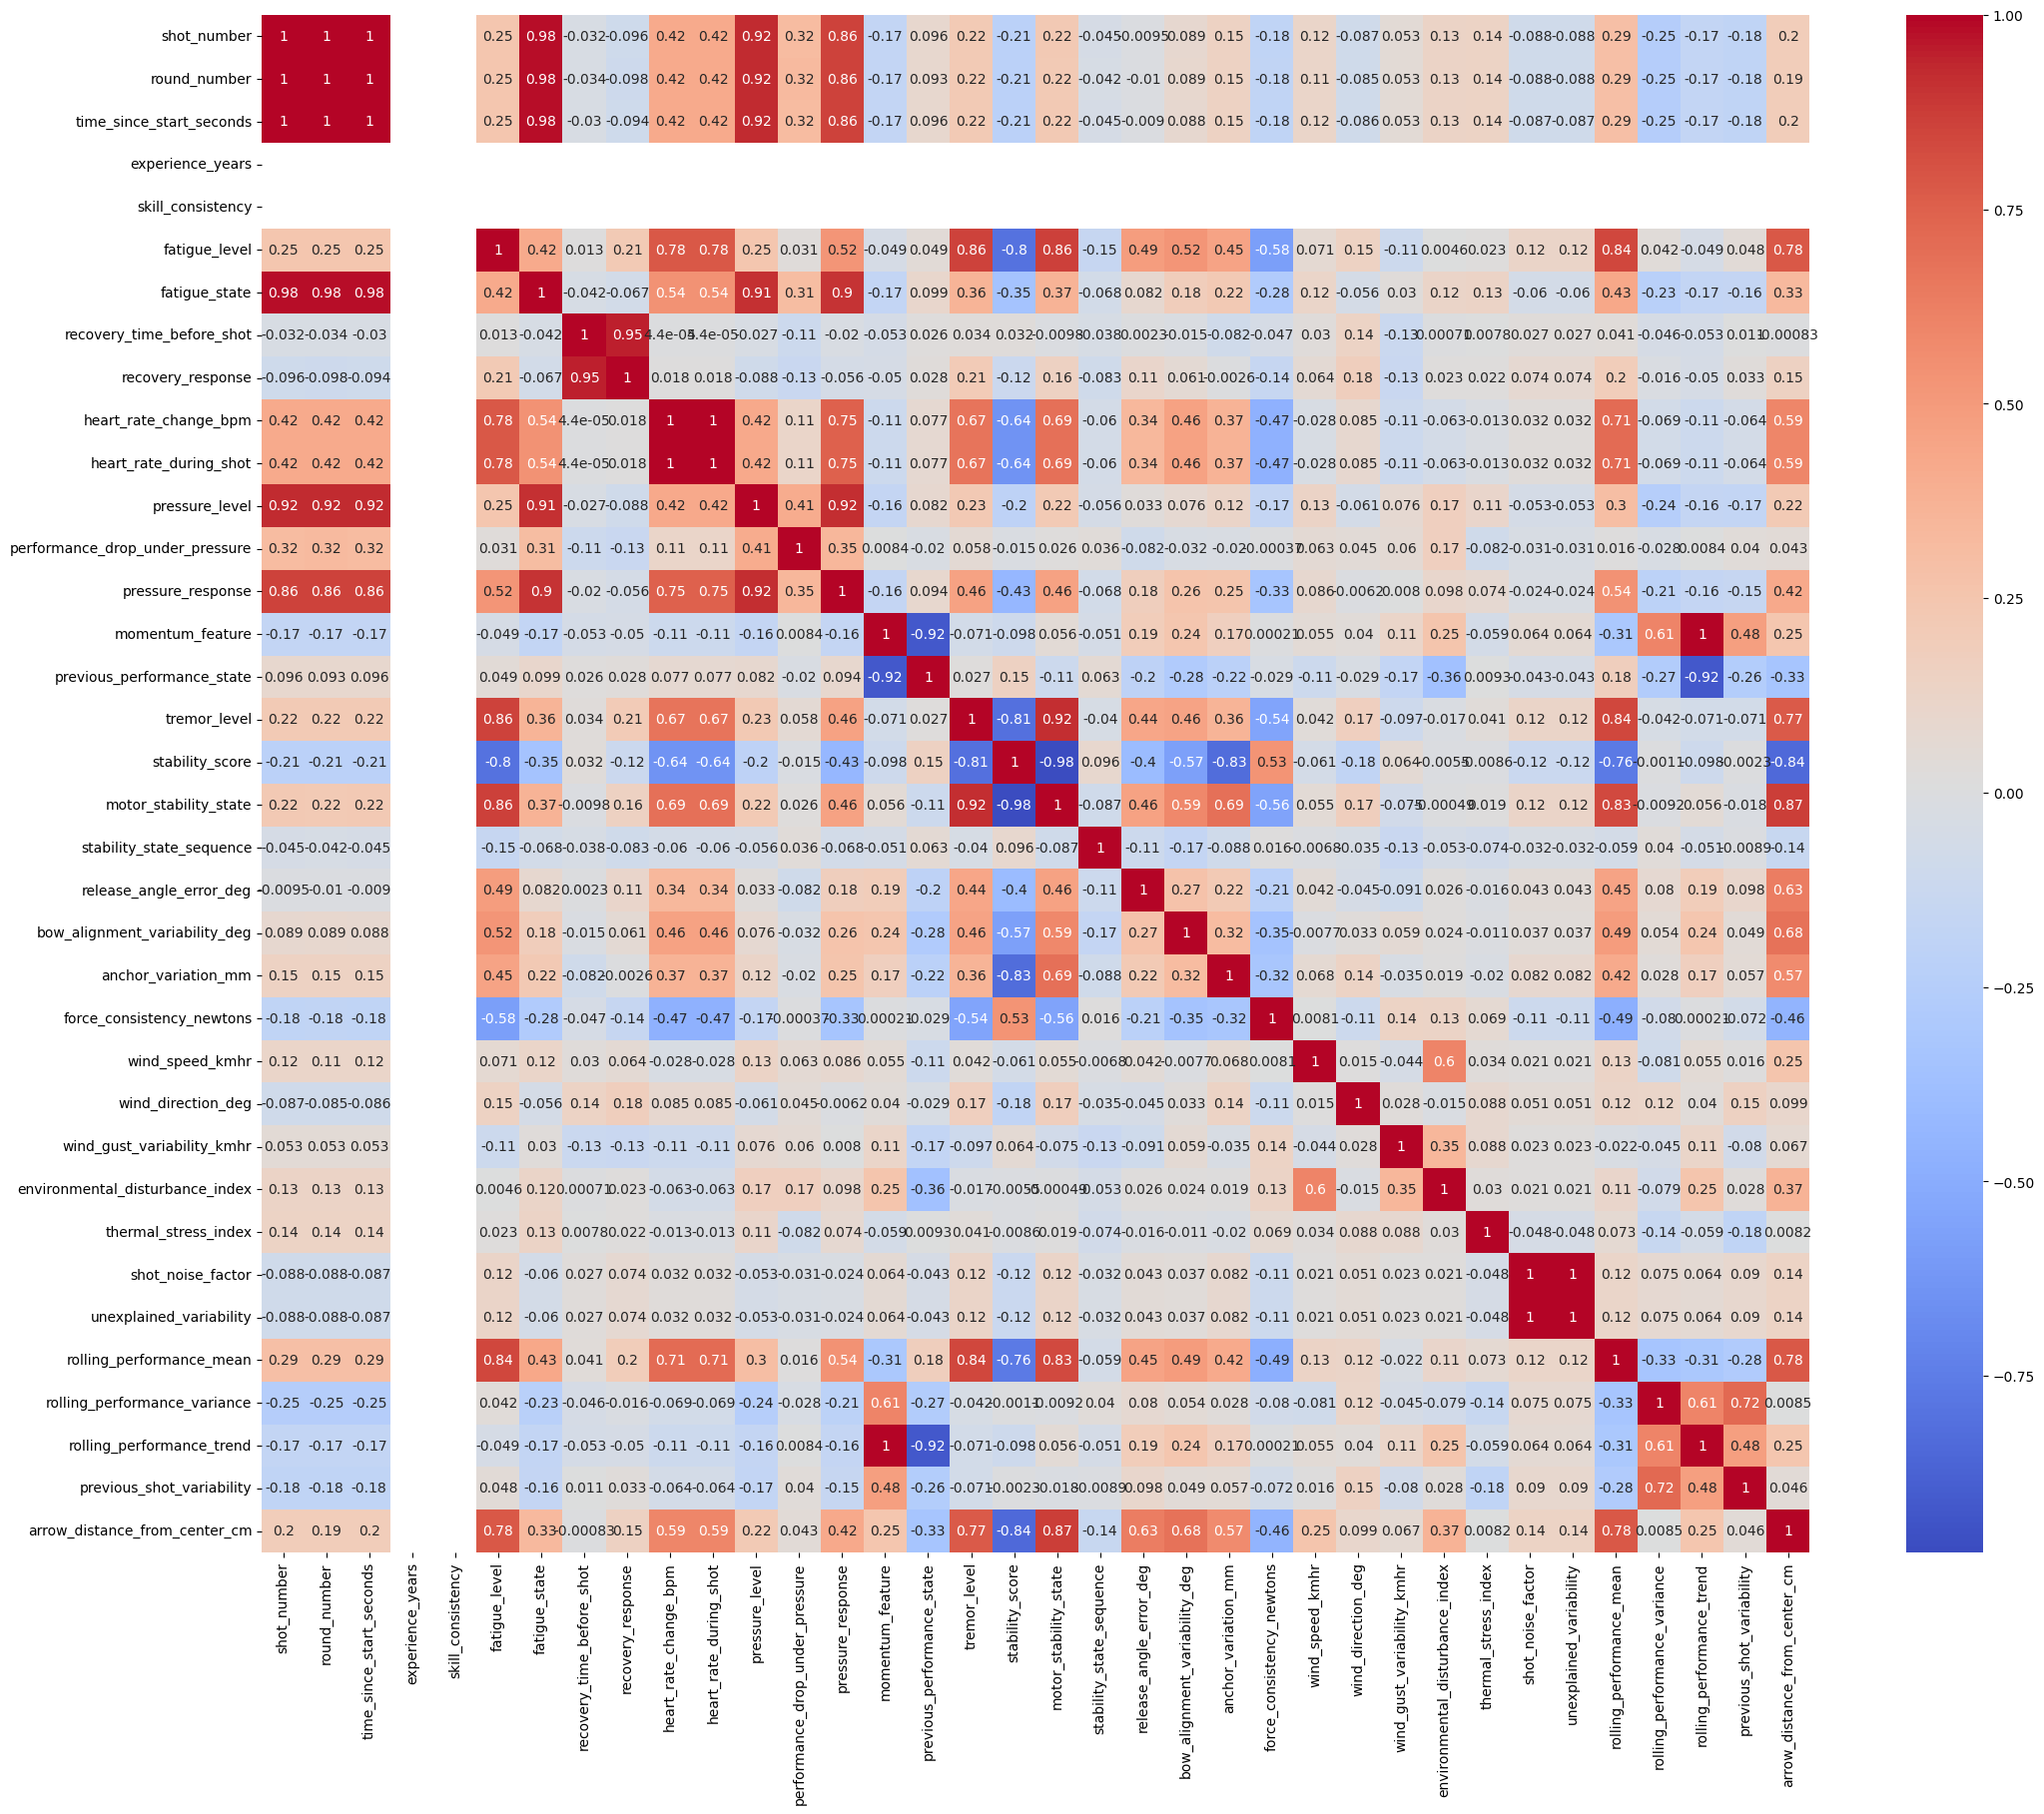

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(25,20))
sns.heatmap(df_archery.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

this graph helped me understand the structural multicollinearity while generating the synthetic dataset, to fulfil the requirements for having such features dependence which help make a kind of environment to learn where machine learning algorithms become limited or sometimes trick us.

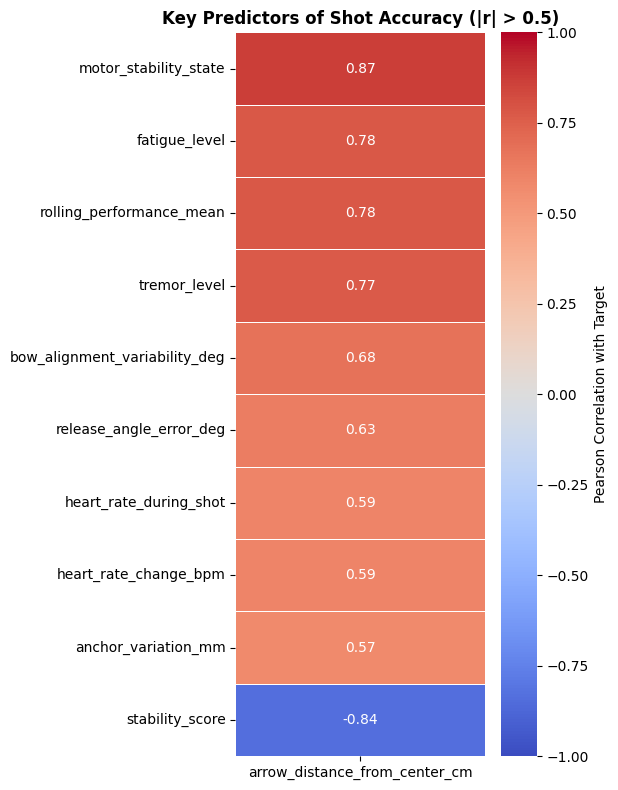

In [4]:
target_col = 'arrow_distance_from_center_cm'

# 1. Calculate correlation with target only
target_corr = df_archery.corr()[[target_col]].drop(index=target_col)

# 2. Filter for correlations greater than 0.5 (or absolute > 0.5)
filtered_target_corr = target_corr[np.abs(target_corr[target_col]) > 0.5].sort_values(by=target_col, ascending=False)

# 3. Plot as a clean single-column heatmap
plt.figure(figsize=(6, 8))
sns.heatmap(
    filtered_target_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Pearson Correlation with Target"}
)

plt.title("Key Predictors of Shot Accuracy (|r| > 0.5)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### dataset performance on linear regression, mean squared error and r2 score

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# ==========================================
# 1. LOAD THE DATASET
# ==========================================
# Assuming you are calling your dynamic laboratory generator function:
# df = generate_fully_dynamic_archery_laboratory(num_shots=500)

# For testing, ensure your DataFrame contains the core layers discussed:
# Features: fatigue_level, pressure_level, tremor_level, anchor_variation, wind_speed, etc.
# Target: arrow_distance_from_center

# Let's verify feature presence and drop the target to separate X and y
target_column = 'arrow_distance_from_center_cm'

# Make sure you have already generated or loaded your dataset 'df'
# Example placeholder if running in isolation:
# df = pd.read_csv("archery_simulation_data.csv")

# Defining our Feature Matrix (X) and Target Vector (y)
# Exclude target and any non-predictive sequencing tokens like 'shot_number' if preferred
X = df_archery.drop(columns=[target_column])
y = df_archery[target_column]

print(f"Dataset Loaded Successfully.")
print(f"Features shape: {X.shape} | Target shape: {y.shape}\n")

Dataset Loaded Successfully.
Features shape: (200, 35) | Target shape: (200,)



### what are learned systems coefficients & How They Are Calculated?

The learned coefficients are the slopes (beta values) assigned to each feature in the dataset by an Ordinary Least Squares (OLS) Linear Regression model (LinearRegression() from scikit-learn).

Mathematically, the linear regression model assumes that the target variable (arrow distance from center) can be predicted as a weighted linear combination of all the features :
yhat = beta0 + beta1*x1 + bet2 * x2 + ... + betan * xn

Calculation: When we execute model.fit(X, y) in the code, the algorithm uses matrix inversion to solve the normal equation:
beta = Xtranspose * X ka inverse * Xtranspose * y

inside the code block, these are pulled directly via model.coef_ and zipped with their respective column names to print the list.

In [15]:
# ==========================================
# 2. INITIALIZE AND TRAIN THE ML MICROSCOPE
# ==========================================
# Initialize the standard OLS Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X, y)

# Generate performance predictions
y_pred = model.predict(X)

# Calculate standard metrics
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("--- Baseline Model Diagnostics ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R²) Score:     {r2:.4f}")

# Display feature weights to analyze what the linear model prioritizes
print("\n--- Learned System Coefficients ---")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature:<30} : {coef:.4f}")
print(f"{'Intercept':<30} : {model.intercept_:.4f}\n")

--- Baseline Model Diagnostics ---
Mean Squared Error (MSE): 0.0282
R-squared (R²) Score:     0.9961

--- Learned System Coefficients ---
shot_number                    : -200361.0647
round_number                   : 0.0043
time_since_start_seconds       : -20036.1084
experience_years               : 0.0009
skill_consistency              : 0.0000
fatigue_level                  : -200361082.3884
fatigue_state                  : 200361081.3370
recovery_time_before_shot      : 100180.5283
recovery_response              : 11.4001
heart_rate_change_bpm          : -200359.7398
heart_rate_during_shot         : -200359.7402
pressure_level                 : 267.0878
performance_drop_under_pressure : 132.8332
pressure_response              : -668.0372
momentum_feature               : -0.0291
previous_performance_state     : -0.0749
tremor_level                   : 0.8927
stability_score                : -0.8310
motor_stability_state          : 3.6921
stability_state_sequence       : 0.0718
relea

### the problem faced: extreme multicolliniarity

the engineered features are near perfect linear combinations of each other. so when ordinary least suare tries to compute X transpose* X ka inverse, it finds that columns are moving together, which means matrix become nearly singular. The independent effect of fatigue level and fatigue state become isolated.


In [16]:
# ==========================================
# 3. COMPUTE RESIDUALS & BIOLOGICAL DRIFT
# ==========================================
# Residuals = Actual Outcome - Predicted Linear Vector
df_archery['predictions'] = y_pred
df_archery['residuals'] = y - y_pred

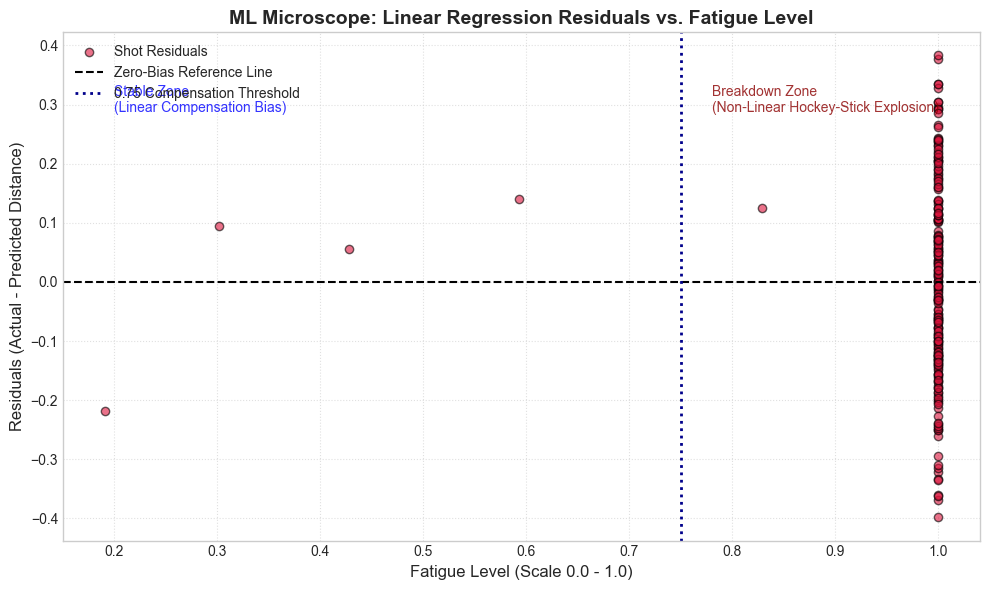

In [17]:
# ==========================================
# 4. DIAGNOSTIC MICROSCOPE VISUALIZATION
# ==========================================
plt.figure(figsize=(10, 6))

# Plot Residuals vs Fatigue Level to catch the structural phase breakdown cliff
plt.scatter(df_archery['fatigue_level'], df_archery['residuals'], color='crimson', alpha=0.6, edgecolors='k', label='Shot Residuals')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Zero-Bias Reference Line')

# Highlight the 0.75 biological compensation threshold boundary
plt.axvline(0.75, color='darkblue', linestyle=':', linewidth=2, label='0.75 Compensation Threshold')

plt.title('ML Microscope: Linear Regression Residuals vs. Fatigue Level', fontsize=14, fontweight='bold')
plt.xlabel('Fatigue Level (Scale 0.0 - 1.0)', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted Distance)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')

# Annotate structural behaviors for validation
plt.text(0.2, df_archery['residuals'].max() * 0.75, 'Stable Zone\n(Linear Compensation Bias)', color='blue', alpha=0.8)
plt.text(0.78, df_archery['residuals'].max() * 0.75, 'Breakdown Zone\n(Non-Linear Hockey-Stick Explosion)', color='darkred', alpha=0.8)

plt.tight_layout()
plt.show()


### how it is fixed:

*/ feature exclusion: remove raw target-generating structural states fatigue state and downstream mechanics like release_angle_error_deg before training the model

*/ ridge regression: Ridge adds an L2 penalty onto the diagonal of the matrix before inversion, which cap the coefficients so they can never explode into the millions and stabilize the model weights

*/ Drop the raw target-generating hidden states, deterministic sequences, and highly collinear data leaks: 
fatigue_state,
heart_rate_during_shot,
shot_number,
and time_since_start_seconds

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge  # MODIFIED: Swapped to Ridge Regression
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 1. LOAD THE DATASET
# ==========================================
# (Assuming your dataset 'df_archery' is already generated or loaded)
target_column = 'arrow_distance_from_center_cm'

# --- THE REMOVAL STEP (FEATURE EXCLUSION) ---
# Identify and remove perfect linear combinations, non-predictive sequencing tokens, 
# and target-generating latent leaks that cause numerical singularity.
features_to_drop = [
    target_column,
    'shot_number', 
    'time_since_start_seconds', 
    'fatigue_state',            # Leaks structural threshold state
    'heart_rate_during_shot',   # Perfectly collinear with heart_rate_change_bpm
]

# Ensure we only drop columns if they actually exist in your dataframe
existing_drops = [col for col in features_to_drop if col in df_archery.columns]

# Defining our cleaned Feature Matrix (X) and Target Vector (y)
X = df_archery.drop(columns=existing_drops)
y = df_archery[target_column]

print(f"Dataset Processed Successfully via Feature Exclusion.")
print(f"Features shape: {X.shape} | Target shape: {y.shape}")
print(f"Excluded Columns: {existing_drops}\n")

Dataset Processed Successfully via Feature Exclusion.
Features shape: (200, 33) | Target shape: (200,)
Excluded Columns: ['arrow_distance_from_center_cm', 'shot_number', 'time_since_start_seconds', 'fatigue_state', 'heart_rate_during_shot']



### note
the features creating leaks are removed in the training process

In [19]:
# ==========================================
# 2. INITIALIZE AND TRAIN THE ML MICROSCOPE
# ==========================================
# MODIFIED: Use Ridge Regression with an L2 penalty to stabilize weights
# alpha=1.0 controls regularization strength; adjust if you want more/less constraint
model = Ridge(alpha=1.0)

# Train the stabilized model
model.fit(X, y)

# Generate performance predictions
y_pred = model.predict(X)

# Calculate standard metrics
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("--- Stabilized Model Diagnostics ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R²) Score:      {r2:.4f}")

# Display feature weights to analyze what the linear model prioritizes now
print("\n--- Stabilized Learned System Coefficients ---")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature:<30} : {coef:.4f}")
print(f"{'Intercept':<30} : {model.intercept_:.4f}\n")


--- Stabilized Model Diagnostics ---
Mean Squared Error (MSE): 0.0007
R-squared (R²) Score:      0.9999

--- Stabilized Learned System Coefficients ---
round_number                   : -0.0001
experience_years               : -0.0000
skill_consistency              : -0.0000
fatigue_level                  : 0.0021
recovery_time_before_shot      : 0.0000
recovery_response              : -0.0002
heart_rate_change_bpm          : -0.0000
pressure_level                 : 0.0016
performance_drop_under_pressure : -0.0000
pressure_response              : 0.0006
momentum_feature               : 0.0022
previous_performance_state     : 0.0014
tremor_level                   : 0.0140
stability_score                : -0.0068
motor_stability_state          : 0.0256
stability_state_sequence       : -0.0030
release_angle_error_deg        : 0.0491
bow_alignment_variability_deg  : 0.0436
anchor_variation_mm            : 0.0102
force_consistency_newtons      : -0.0001
wind_speed_kmhr                : 0.000

In [20]:
# ==========================================
# 3. COMPUTE RESIDUALS & BIOLOGICAL DRIFT
# ==========================================
# Residuals = Actual Outcome - Predicted Linear Vector
df_archery['predictions'] = y_pred
df_archery['residuals'] = y - y_pred

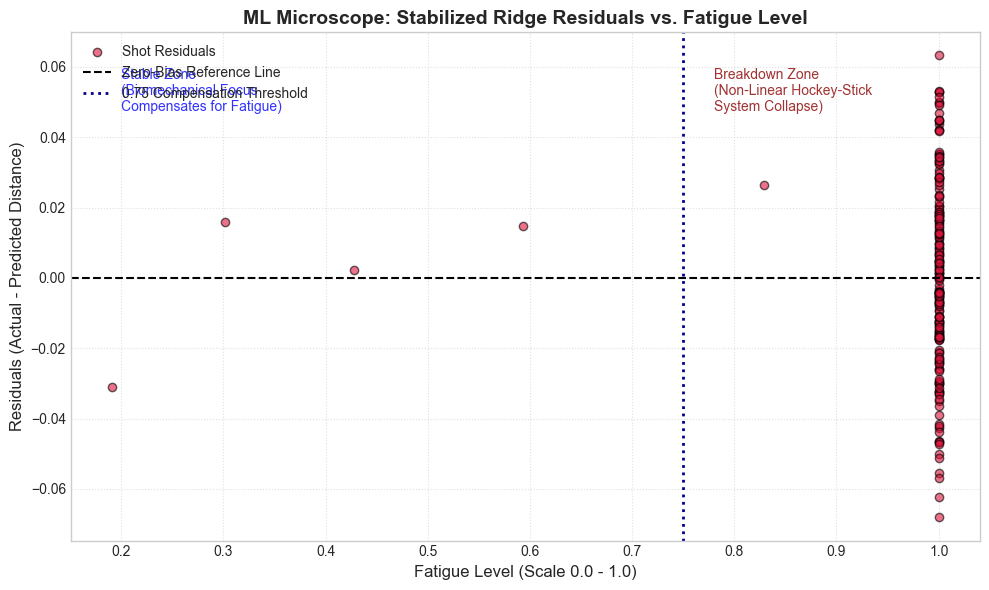

In [21]:

# ==========================================
# 4. DIAGNOSTIC MICROSCOPE VISUALIZATION
# ==========================================
plt.figure(figsize=(10, 6))

# Plot Residuals vs Fatigue Level to catch the structural phase breakdown cliff
plt.scatter(df_archery['fatigue_level'], df_archery['residuals'], color='crimson', alpha=0.6, edgecolors='k', label='Shot Residuals')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Zero-Bias Reference Line')

# Highlight the 0.75 biological compensation threshold boundary
plt.axvline(0.75, color='darkblue', linestyle=':', linewidth=2, label='0.75 Compensation Threshold')

plt.title('ML Microscope: Stabilized Ridge Residuals vs. Fatigue Level', fontsize=14, fontweight='bold')
plt.xlabel('Fatigue Level (Scale 0.0 - 1.0)', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted Distance)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')

# Annotate structural behaviors for validation
# Using dynamic coordinates based on actual residual ranges to avoid positioning bugs
max_res = df_archery['residuals'].max()
plt.text(0.2, max_res * 0.75, 'Stable Zone\n(Biomechanical Focus\nCompensates for Fatigue)', color='blue', alpha=0.8)
plt.text(0.78, max_res * 0.75, 'Breakdown Zone\n(Non-Linear Hockey-Stick\nSystem Collapse)', color='darkred', alpha=0.8)

plt.tight_layout()
plt.show()